### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [98]:
# Step 1
def get_label_array(N, p):
    label_base = np.random.rand(N)
    return [1 if val < p else 0 for val in label_base]

In [99]:
# Step 2
def get_data(N, epsilon, p):
    labels = get_label_array(N, p)
    mu_0 = np.array([0, 0])
    mu_1 = np.array([epsilon, 0])
    sigma_0 = .5 * np.identity(2)
    sigma_1 = .4 * np.identity(2)
    x = []
    for l in labels:
        if l:
            sample = np.random.multivariate_normal(mu_1, sigma_1)
        else:
            sample = np.random.multivariate_normal(mu_0, sigma_0)
        x.append(sample)
        
    return np.array(x), labels

# Training data
D_train, labels_train = get_data(50, 2, .3)
# Testing data
D_test, labels_test = get_data(10**3, 2, .3)

print(D_train, D_test)


[[-0.44168761 -0.88023742]
 [ 3.71017714  1.12804105]
 [ 0.02503451 -0.18630615]
 [-0.1153545   1.38395234]
 [ 0.04372666 -0.90876742]
 [-1.10111155 -0.50762861]
 [ 0.11104212 -0.20888512]
 [ 2.25942367 -1.17524306]
 [-1.02724391  0.41672317]
 [ 2.81694698 -1.20491156]
 [-0.45913771  0.43445697]
 [-0.1631799  -0.22897472]
 [ 1.8698274   0.08483495]
 [ 0.52151681 -0.25593635]
 [ 0.43111683  0.18434797]
 [ 0.36294633  0.3800854 ]
 [ 1.96258856 -0.08119958]
 [ 1.26198734  0.49317014]
 [-0.27563114 -0.73133049]
 [-0.08794072  0.27986727]
 [-1.00464715  0.00565261]
 [ 2.2028765  -0.62097015]
 [-0.33820022 -0.27941641]
 [ 0.39672185 -0.56988333]
 [ 1.69552779 -0.0716377 ]
 [ 1.99131306  0.63974173]
 [ 0.25401864  0.17829418]
 [-1.14231763  0.38262741]
 [-2.42461463 -0.22943775]
 [ 1.05500563  0.22043504]
 [-0.47691257 -0.20032594]
 [ 2.27189845  0.54565191]
 [-1.60322456  0.03553193]
 [ 2.32215838 -0.30307099]
 [ 0.06517411 -1.71459365]
 [ 0.1863751  -0.70646076]
 [ 0.01104806 -0.15098944]
 

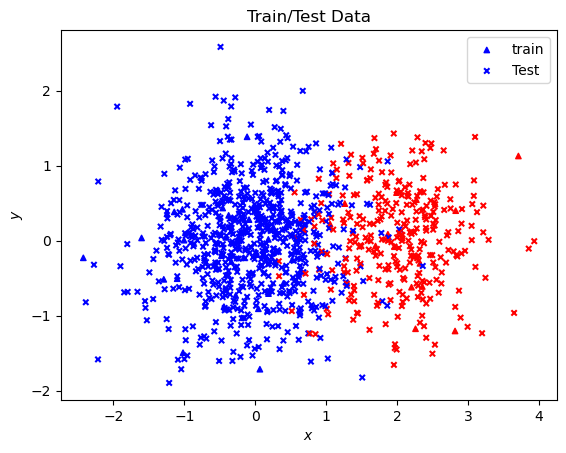

In [100]:
# Train points
plt.scatter(D_train[:, 0], D_train[:, 1],
            c=labels_train, cmap='bwr',
            marker='^', s=15, label='train')

# Test points
plt.scatter(D_test[:, 0], D_test[:, 1],
            c=labels_test, cmap='bwr',
            marker='x', s=15, label='Test')

plt.legend()
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Train/Test Data")
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

## Bayes Classifier and Decision Boundary

### Likelihoods

For each class:
\begin{equation*}
f_0(\mathbf{x}) = \frac{1}{2\pi \sqrt{\det \Sigma_0}}
\exp\left(-\tfrac{1}{2}(\mathbf{x}-\mu_0)^\top \Sigma_0^{-1}(\mathbf{x}-\mu_0)\right)
\end{equation*}

\begin{equation*}
f_1(\mathbf{x}) = \frac{1}{2\pi \sqrt{\det \Sigma_1}}
\exp\left(-\tfrac{1}{2}(\mathbf{x}-\mu_1)^\top \Sigma_1^{-1}(\mathbf{x}-\mu_1)\right)
\end{equation*}

### Bayes Classifier

Classify $\mathbf{x}$ as class 1 if:
\begin{equation*}
\frac{f_1(\mathbf{x})\times p}{f_0(\mathbf{x})\times(1-p)} > 1
\end{equation*}

Equivalently, using logs:
\begin{equation*}
g(\mathbf{x}) > 0
\end{equation*}

where

\begin{equation*}
g(\mathbf{x}) =
\log\frac{p}{1-p}

+ \log\sqrt{\frac{\det \Sigma_0}{\det \Sigma_1}}

- \tfrac{1}{2}(\mathbf{x}-\mu_1)^\top \Sigma_1^{-1}(\mathbf{x}-\mu_1)

+ \tfrac{1}{2}(\mathbf{x}-\mu_0)^\top \Sigma_0^{-1}(\mathbf{x}-\mu_0)
\end{equation*}

### With Given Parameters

$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0\\0\end{array}\right] \\
\quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \\
\quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] = .5 * I_2 \\
\quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right] = .4 * I_2 \\
$$

\begin{equation*}
\sqrt{\det \Sigma_0} = 0.5, \quad \sqrt{\det \Sigma_1} = 0.4
\end{equation*}

So $g$ becomes:

\begin{align*}
g(\mathbf{x}) &=
\log\frac{p}{1-p}

+ \log\left(\frac{5}{4}\right)

- \tfrac{1}{2}*\tfrac{10}{4}|\mathbf{x} - (\varepsilon,0)|^2

+ \tfrac{1}{2}*\tfrac{10}{5}|\mathbf{x}|^2\\

&=
\log\frac{p}{1-p}

+ \log\left(\frac{5}{4}\right)

- \tfrac{5}{4}|\mathbf{x} - (\varepsilon,0)|^2

+ |\mathbf{x}|^2
\end{align*}


### Decision Boundary

The decision boundary is given by:
\begin{equation*}
g(\mathbf{x}) = 0
\end{equation*}

So, 

\begin{equation*}
\log\frac{p}{1-p}

+ \log\left(\frac{5}{4}\right)

- \tfrac{5}{4}|\mathbf{x} - (\varepsilon,0)|^2

+ |\mathbf{x}|^2 = 0
\end{equation*}

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [101]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import validate_data, check_is_fitted
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import euclidean_distances
class BayesClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, p, epsilon):
        self.p = p
        self.epsilon = epsilon

        self.mu_0 = np.array([.0, .0])
        self.mu_1 = np.array([self.epsilon, .0])
        self.sigma_0 = .5 * np.identity(2)
        self.sigma_1 = .4 * np.identity(2)
        self.sq_det_0 = np.sqrt(np.linalg.det(self.sigma_0))
        self.sq_det_1 = np.sqrt(np.linalg.det(self.sigma_1))
        self.sigma_0_inv = np.linalg.inv(self.sigma_0)
        self.sigma_1_inv = np.linalg.inv(self.sigma_1)


    def fit(self, X, y):
        # Check that X and y have correct shape, set n_features_in_, etc.
        # if X and y:
        #     X, y = validate_data(self, X, y)
        
        # Return the classifier
        return self
    
    def g(self, X):
        p_term = np.log(self.p / (1 - self.p))
        det_term = np.log(self.sq_det_0 / self.sq_det_1)
        
        diff1 = X - self.mu_1
        diff0 = X - self.mu_0
        
        quad1 = np.sum(diff1 @ self.sigma_1_inv * diff1, axis=1)
        quad0 = np.sum(diff0 @ self.sigma_0_inv * diff0, axis=1)

        return p_term + det_term - 0.5 * quad1 + 0.5 * quad0
    
    def predict(self, X):
        # Check if fit has been called
        # check_is_fitted(self)
        # Input validation
        X = validate_data(self, X, reset=False)

        return (self.g(X) > 0).astype(int)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

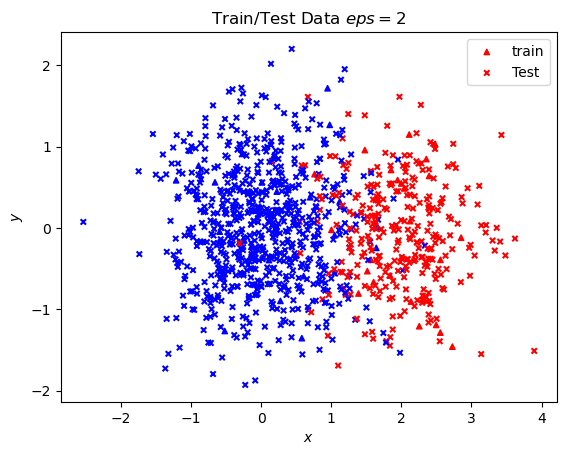

Accuracy: 0.937
Bayes error estimate: 0.06299999999999994


In [102]:
# epsilon = 2
# Generate data
D_train, labels_train = get_data(50, 2, 0.3)
D_test, labels_test = get_data(10**3, 2, 0.3)

# Train classifier
clf = BayesClassifier(p=0.3, epsilon=2.0)
clf.fit(D_train, labels_train)

# Compute accuracy and error
accuracy = clf.score(D_test, labels_test)
error = 1 - accuracy

# Train points
plt.scatter(D_train[:, 0], D_train[:, 1],
            c=labels_train, cmap='bwr',
            marker='^', s=15, label='train')

# Test points
plt.scatter(D_test[:, 0], D_test[:, 1],
            c=labels_test, cmap='bwr',
            marker='x', s=15, label='Test')

plt.legend()
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Train/Test Data $eps = 2$")
plt.show()

print("Accuracy:", accuracy)
print("Bayes error estimate:", error)

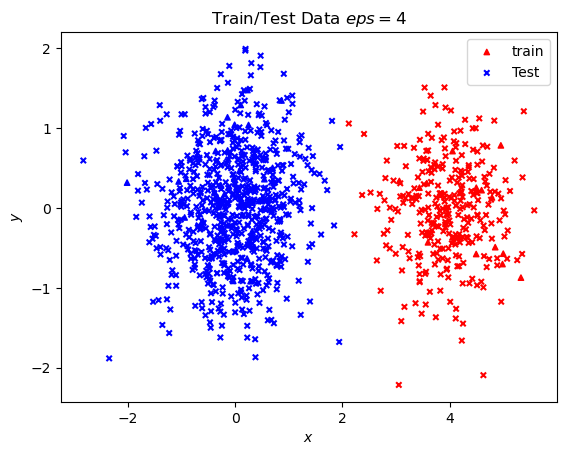

Accuracy: 0.999
Bayes error estimate: 0.0010000000000000009


In [103]:
# epsilon = 4
# Generate data
D_train, labels_train = get_data(50, 4, 0.3)
D_test, labels_test = get_data(10**3, 4, 0.3)

# Train classifier
clf = BayesClassifier(p=0.3, epsilon=4.0)
clf.fit(D_train, labels_train)

# Compute accuracy and error
accuracy = clf.score(D_test, labels_test)
error = 1 - accuracy

# Train points
plt.scatter(D_train[:, 0], D_train[:, 1],
            c=labels_train, cmap='bwr',
            marker='^', s=15, label='train')

# Test points
plt.scatter(D_test[:, 0], D_test[:, 1],
            c=labels_test, cmap='bwr',
            marker='x', s=15, label='Test')

plt.legend()
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Train/Test Data $eps = 4$")
plt.show()

print("Accuracy:", accuracy)
print("Bayes error estimate:", error)

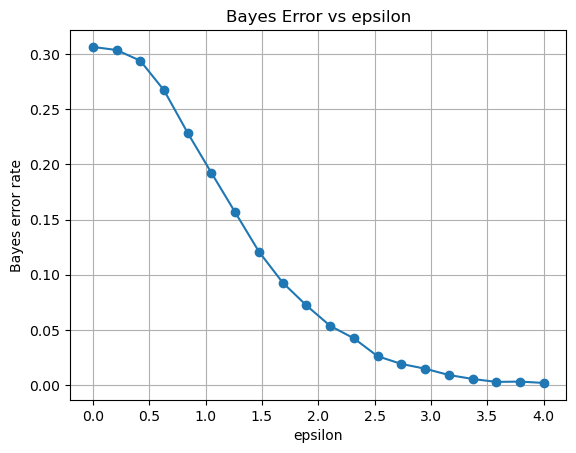

In [104]:
import matplotlib.pyplot as plt

epsilons = np.linspace(0, 4, 20)
errors = []
p = .3
for eps in epsilons:
    # Generate new dataset for each epsilon
    D_test, labels_test = get_data(10**4, eps, p)
    
    clf = BayesClassifier(p=p, epsilon=eps)
    clf.fit(None, None)
    
    error = 1 - clf.score(D_test, labels_test)
    errors.append(error)

plt.figure()
plt.plot(epsilons, errors, marker='o')
plt.xlabel("epsilon")
plt.ylabel("Bayes error rate")
plt.title("Bayes Error vs epsilon")
plt.grid(True)
plt.show()

The curve is monotonically decreasing with a sharp drop for small ε, then flattening
Error approaches 0 as separation becomes large

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

Given the structure of the data-generating model, **QDA (Quadratic Discriminant Analysis)** is the most adequate classifier.

The data is generated as a mixture of two Gaussians with **different** covariance matrices ($\Sigma_0 = 0.5\,I_2$ and $\Sigma_1 = 0.4\,I_2$). The assumptions behind each classifier are:

- **LDA** assumes both classes share the same covariance matrix ($\Sigma_0 = \Sigma_1$), leading to a *linear* decision boundary. This assumption is violated here.
- **QDA** assumes each class has its own covariance matrix, leading to a *quadratic* decision boundary. This matches exactly the structure of our generative model.
- **Logistic Regression** models $P(Y=1 \mid \mathbf{x})$ as a sigmoid of a linear function of $\mathbf{x}$, also imposing a linear boundary. Like LDA, it cannot capture the quadratic boundary arising from unequal covariances.

Since QDA's assumptions exactly match the true data distribution, it should yield the lowest test error among the three, approaching the Bayes error rate.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

Bayes error:  0.0500
LDA error:    0.0660
QDA error:    0.0540
LR error:     0.0550


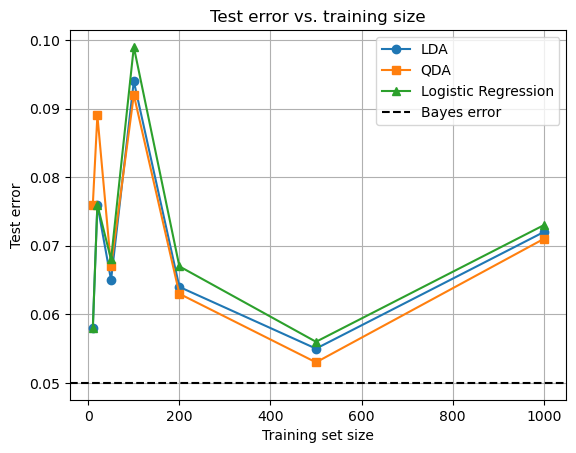

In [105]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# Generate datasets
np.random.seed(42)
D_train, labels_train = get_data(50, 2, 0.3)
D_test, labels_test = get_data(10**3, 2, 0.3)

# Bayes error for reference (from part c)
clf_bayes = BayesClassifier(p=0.3, epsilon=2.0)
clf_bayes.fit(D_train, labels_train)
bayes_error = 1 - clf_bayes.score(D_test, labels_test)

# Train classifiers
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
lr  = LogisticRegression()

lda.fit(D_train, labels_train)
qda.fit(D_train, labels_train)
lr.fit(D_train, labels_train)

# Errors on test set
lda_error = 1 - lda.score(D_test, labels_test)
qda_error = 1 - qda.score(D_test, labels_test)
lr_error  = 1 - lr.score(D_test, labels_test)

print(f"Bayes error:  {bayes_error:.4f}")
print(f"LDA error:    {lda_error:.4f}")
print(f"QDA error:    {qda_error:.4f}")
print(f"LR error:     {lr_error:.4f}")

# Empirical study: vary training size
train_sizes = [10, 20, 50, 100, 200, 500, 1000]
lda_errors, qda_errors, lr_errors = [], [], []

for n in train_sizes:
    D_tr, y_tr = get_data(n, 2, 0.3)
    D_te, y_te = get_data(10**3, 2, 0.3)
    lda_errors.append(1 - LinearDiscriminantAnalysis().fit(D_tr, y_tr).score(D_te, y_te))
    qda_errors.append(1 - QuadraticDiscriminantAnalysis().fit(D_tr, y_tr).score(D_te, y_te))
    lr_errors.append(1 - LogisticRegression().fit(D_tr, y_tr).score(D_te, y_te))

plt.figure()
plt.plot(train_sizes, lda_errors, marker='o', label='LDA')
plt.plot(train_sizes, qda_errors, marker='s', label='QDA')
plt.plot(train_sizes, lr_errors,  marker='^', label='Logistic Regression')
plt.axhline(bayes_error, color='k', linestyle='--', label='Bayes error')
plt.xlabel('Training set size')
plt.ylabel('Test error')
plt.title('Test error vs. training size')
plt.legend()
plt.grid(True)
plt.show()

QDA achieves an error closest to the Bayes error rate, as expected from (d), since its assumptions match the true generative model. LDA and logistic regression both impose a linear boundary and therefore carry a higher irreducible model error due to misspecification.

As the training size $n$ increases, the estimation error (variance component) decreases for all classifiers: parameters are estimated more accurately. By consistency, each classifier converges to the best model within its hypothesis class. For QDA this means converging to the Bayes classifier; for LDA and logistic regression it means converging to the best *linear* boundary, which still has a non-zero gap from the Bayes error due to bias (model misspecification). The empirical curves confirm this: QDA's error converges toward the Bayes error, while LDA and LR plateau above it.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [106]:
# New test set: epsilon=0.5, p=0.7
D_test_new, labels_test_new = get_data(1000, 0.5, 0.7)

lda_error_new = 1 - lda.score(D_test_new, labels_test_new)
qda_error_new = 1 - qda.score(D_test_new, labels_test_new)
lr_error_new  = 1 - lr.score(D_test_new, labels_test_new)

clf_bayes_new = BayesClassifier(p=0.7, epsilon=0.5)
clf_bayes_new.fit(D_test_new, labels_test_new)
bayes_error_new = 1 - clf_bayes_new.score(D_test_new, labels_test_new)

print(f"New Bayes error:  {bayes_error_new:.4f}")
print(f"New LDA error:    {lda_error_new:.4f}")
print(f"New QDA error:    {qda_error_new:.4f}")
print(f"New LR error:     {lr_error_new:.4f}")

New Bayes error:  0.2720
New LDA error:    0.5730
New QDA error:    0.6250
New LR error:     0.6200


The classifiers were trained on $\mathcal{D}_\text{train} = \mathcal{D}(50 \mid \varepsilon=2,\, p=0.3)$ but are now evaluated on $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid \varepsilon=0.5,\, p=0.7)$, which has a different class prior and much smaller class separation.

We observe a significant increase in test error for all classifiers. There are two reasons:

1. **Distribution shift**: The test distribution differs from the training distribution (different $\varepsilon$ and $p$). The decision boundaries were optimized for $p=0.3$; with $p=0.7$ the class balance is inverted and the boundaries are no longer well-calibrated.
2. **Harder problem**: With $\varepsilon=0.5$, the two Gaussians overlap much more, so even the Bayes error is much higher on this new test set.

This illustrates the importance of the i.i.d. assumption: when the train and test distributions differ, performance can degrade substantially even for well-specified models.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 1 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

---------------
##### $\hookrightarrow$ Import Data

In [107]:
train_data = pd.read_csv("titanic/train.csv")
test_data = pd.read_csv("titanic/test.csv")

##### $\hookrightarrow$ Exploratory Data Analysis

In [108]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


We can see that the dataset contains 891 samples and 12 features. The features are comprised by different types and not all of them are complete.

$\rightarrow$ The non-numerical features are: Name, Sex, Ticket, Cabin, and Embarked. 

$\rightarrow$ The incomplete features are: Age, Cabin, and Embarked.

In [109]:
train_data.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [110]:

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


It is also interesting to note that the dataset is imbalanced, with only 38% of the passengers surviving.

It is possible to see that the feature Fare has a very high variance. It might be important to adjust the variance of this feature.

Analyzing the dataset, we can see that there are different features that correlate, considering that multiple passengers might share the same family (can be seen through the last name, ticket number, SibSp and Parch). We can join this passengers into families and use this as a new feature for our model.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Fare'}>],
       [<Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>]], dtype=object)

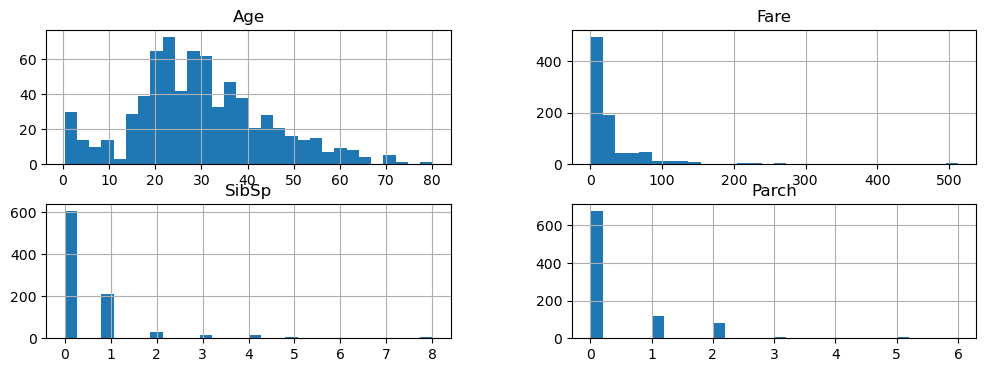

In [111]:
train_data[["Age", "Fare", "SibSp", "Parch"]].hist(bins=30, figsize=(12, 4))

In [112]:
for col in ["Sex", "Pclass", "Embarked"]:
    print(train_data.groupby(col)["Survived"].mean().sort_values())

Sex
male      0.188908
female    0.742038
Name: Survived, dtype: float64
Pclass
3    0.242363
2    0.472826
1    0.629630
Name: Survived, dtype: float64
Embarked
S    0.336957
Q    0.389610
C    0.553571
Name: Survived, dtype: float64


74% female passengers survived, in comparison to only 18% of the male passengers.

Also, more passangers of the first class survived than those of the second and third class, showing a correlation between the class of the passenger and its survival.

It's also possible to see that the age distribution of the passengers is skewed towards younger ages, with a peak around 20-30 years old. This evidences the "women and children first" policy. 

It's also possible to see that the people who embarked from Cherbourg had a higher survival rate than those who embarked from Southampton and Queenstown.

In [113]:
corr = train_data.corr(numeric_only=True)
print(corr["Survived"].sort_values())

Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
PassengerId   -0.005007
Parch          0.081629
Fare           0.257307
Survived       1.000000
Name: Survived, dtype: float64


Through the corelation of each feature to survived, we can see that the features that are the most linearly correlated to the survival of the passengers are Pclass and Fare.

After the exploratory data analysis, we can arrive at the following conclusions:

- The dataset is unbalanced and we should use StratifiedKFold for cross-validation.
- We should scale features (such as fare) in order to adjust their variance.
- We can create a new feature that represents the family of the passengers, which might be useful for our model. And this also implies that we should take it into consideration for the cross validation (by using StratifiedGroupKFold). 
- We need to complete the values of the features Age, Cabin, and Embarked. We can use different strategies for each feature and since cabin is a very sparse feature, it might be better to just drop it from our dataset.

##### $\hookrightarrow$ Feature Engineering


Extract the title of the passengers from their name and use it as a new feature.

In [114]:
def extract_titles(df):
    #checks for a word followed by a dot in the name and extracts it as the title of the passenger
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

    #optional reduce nuumber of titles by grouping them

<>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/tmp/ipykernel_20064/3165366423.py:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Create features familyID and familySize.

In [115]:
def create_FamilySize_FamilyID(df):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    print(df['FamilySize'].value_counts())

    #optional, categorize families

    df['Surname'] = df['Name'].apply(lambda x: x.split(',')[0].strip())

    # Combine Surname and FamilySize to create the FamilyID. This will give us a unique identifier for each family, even if the family names are the same.
    df['FamilyID'] = df['Surname'] + "_" + df['FamilySize'].astype(str)

Group tickets

In [116]:
def create_TicketID_TicketGroupSize(df):
    df['TicketID'] = pd.factorize(df['Ticket'])[0]
    df['TicketGroupSize'] = df.groupby('Ticket')['Ticket'].transform('count')


Use title in order to fill in missing values of age Fill missing values for embarked as the most common value (S)

In [117]:
def fill_empty_values_for_Age_and_Embarked(df):
    #age
    Age_median = df.groupby('Title')['Age'].transform('median')
    df['Age'] = df['Age'].fillna(Age_median)

    #embarked
    most_frequent_port = df['Embarked'].mode()[0] # Get the first value from the mode, which is the most frequent value in the 'Embarked' column
    df['Embarked'] = df['Embarked'].fillna(most_frequent_port)

In [118]:
def Feature_engineering(df):
    extract_titles(df)
    create_FamilySize_FamilyID(df)
    create_TicketID_TicketGroupSize(df)
    fill_empty_values_for_Age_and_Embarked(df)
    df = df.drop(['Name','Surname', 'SibSp', 'Parch', 'Cabin', 'Ticket'], axis=1)
    print(df)

Applying Feature engineering to the dataset:


In [119]:

Feature_engineering(train_data)

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64
     PassengerId  Survived  Pclass     Sex   Age     Fare Embarked Title  \
0              1         0       3    male  22.0   7.2500        S    Mr   
1              2         1       1  female  38.0  71.2833        C   Mrs   
2              3         1       3  female  26.0   7.9250        S  Miss   
3              4         1       1  female  35.0  53.1000        S   Mrs   
4              5         0       3    male  35.0   8.0500        S    Mr   
..           ...       ...     ...     ...   ...      ...      ...   ...   
886          887         0       2    male  27.0  13.0000        S   Rev   
887          888         1       1  female  19.0  30.0000        S  Miss   
888          889         0       3  female  21.0  23.4500        S  Miss   
889          890         1       1    male  26.0  30.0000        C    Mr   
890          891         0       3   

$\hookrightarrow$ Pipeline and Model Selection


In [ ]:
# Separate features and target variable
X_train = train_data.drop(['Survived', 'PassengerId'], axis=1)
print (X_train.columns)

y_train = train_data['Survived']

groups = train_data['TicketID']

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked',
       'Title', 'FamilySize', 'FamilyID', 'TicketID', 'TicketGroupSize'],
      dtype='str')


In [132]:
from skrub import tabular_pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

model = tabular_pipeline('classification')

cv = StratifiedGroupKFold(n_splits=5)

scores = cross_val_score(model, X_train, y_train, groups=groups, cv=cv, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean accuracy:", np.mean(scores))

Cross-validation scores: [0.79888268 0.83240223 0.84180791 0.80337079 0.80337079]
Mean accuracy: 0.815966879767869


#fit model


In [133]:

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tablevectorizer', ...), ('histgradientboostingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cardinality_threshold,40
,low_cardinality,ToCategorical()
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncoder()
,specific_transformers,()
,drop_null_fraction,1.0


$\hookrightarrow$ Generate Predictions for Test Set

In [ ]:
#apply the same feature engineering to the test set
Feature_engineering(test_data)

# Extract the PassengerId from the test set to use it for the submission file
test_ids = test_data['PassengerId']

X_test = test_data.drop(['PassengerId'], axis=1)

predictions = model.predict(X_test)

# Create the Kaggle submission dataframe
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': predictions
})

# Export to CSV without the index
submission.to_csv('my_skrub_submission.csv', index=False)
print("Submission saved successfully!")

FamilySize
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64
     PassengerId  Pclass     Sex   Age      Fare Embarked   Title  FamilySize  \
0            892       3    male  34.5    7.8292        Q      Mr           1   
1            893       3  female  47.0    7.0000        S     Mrs           2   
2            894       2    male  62.0    9.6875        Q      Mr           1   
3            895       3    male  27.0    8.6625        S      Mr           1   
4            896       3  female  22.0   12.2875        S     Mrs           3   
..           ...     ...     ...   ...       ...      ...     ...         ...   
413         1305       3    male  28.5    8.0500        S      Mr           1   
414         1306       1  female  39.0  108.9000        C    Dona           1   
415         1307       3    male  38.5    7.2500        S      Mr           1   
416         1308       3    male  28.5    8.0500        S      

#### $\hookrightarrow$ Results!

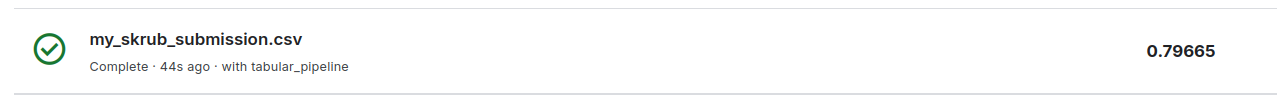

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

The feature engineering steps were defined taking into consideration the data analysis done before.The steps are:
- extracting titles from names: which helps in understanding the social status of passengers, as well as defining a better selection for the age of each passenger with age not defined.
- creating family size and family ID features: which helps in understanding the families in the dataset and the relation between who survives inside the family. FamilySize is the columns SibSp + Parch joined, and familyID is the last name of the passenger + the family size. This is useful because we can see that passengers that are in the same family have a similar survival outcome.
- TicketID and TicketGroupSize: which helps in understanding the groups of passengers that might have been together during the shipwreck, and thus might have similar survival outcomes. This was used as the parameter for the StratifiedGroupKFold cross validation.
- The age feature was completed using the most common age for each title, which is a good strategy considering some titles indicate a certain age range (for instance, Master is usually used for children). Embark was completed using the most common value (in this case 'S').

The model is trained using a tabular pipeline from the skrub library. Each encoder was decided in the table_vectorizer of the pipeline, and the decided encoders were:

For the numerical features, the PassThrough() encoder was used. This happenned because the classification model selected by the pipeline is a gradient boosting model, which is a tree-based model and is not sensitive to the scale of the features. The fucntions documentation explicits that the a scaler for numerical features, in this context, is not necessary.

For low cardinality features, toCategorical() encoder was used, which converts the features into categorical variables that are suitable for histGradientBoostingClassifier. This is explicited in the documentation of the function, which states that this encoder is always safe to use for low cardinality features.

For high cardinality features, the stringEncoder() was used, which does tf-idf vectorization and truncated singular value decomposition (SVD) to encode the features. This is useful for high cardinality features because it allows us to reduce the dimensionality of the feature space while still capturing the most important information from the original features. When testing, we observed that the StringEncoder was very effective into finding meaningful parameters in the dataset, so for example, taking out the columns "Name", "Ticket", and "Cabin" actually made the model perform worse.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

The classifier used was the HistGradientBoostingClassifier, which is a gradient boosting model. This model was selected by the skrub pipeline after testing different models and selecting the one with the best performance on the validation set. The score obtained in the public leaderboard from Kaggle was 0.79665.

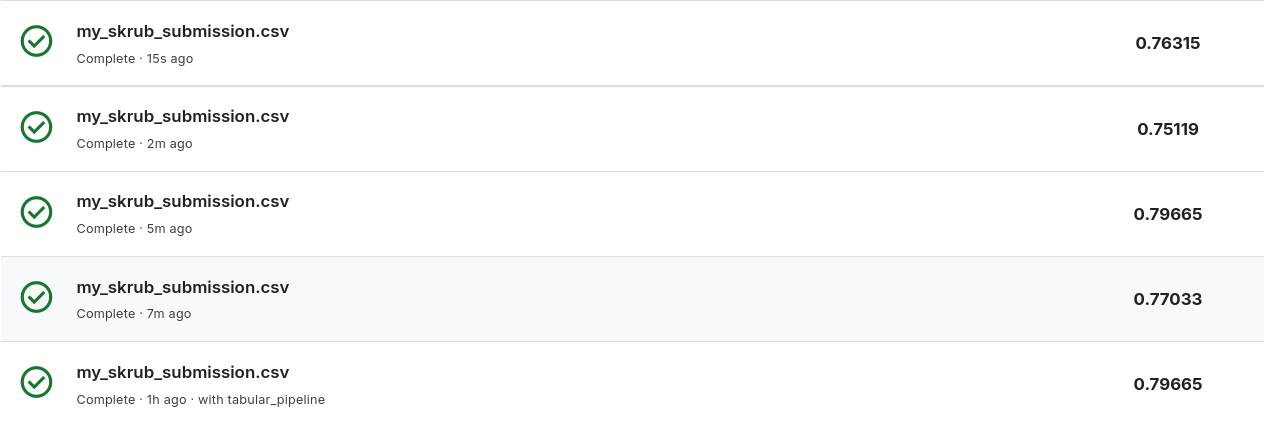